In [1]:
# ============================================================
# Cell 1
# RQ1 city-level comparison summary:
# LST vs Heat Index hotspot mismatch metrics
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files exists:\n" + "\n".join(str(x) for x in candidates)
    )

def pick_first_column(gdf, candidates, label, required=True):
    for c in candidates:
        if c in gdf.columns:
            return c
    if required:
        raise ValueError(
            f"Could not find a valid {label} column. Tried: {candidates}\n"
            f"Available columns are:\n{list(gdf.columns)}"
        )
    return None

def load_city_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()

    lst_col = pick_first_column(
        gdf,
        ["lst_c", "lst_value", "lst_summer_median_c", "median_lst_c", "median_lst", "lst_median_c"],
        "LST"
    )
    hi_col = pick_first_column(
        gdf,
        ["hi_c", "hi_value", "hi_summer_median_c", "median_hi_c", "hi_median_c", "median_heat_index_c", "heat_index_median_c"],
        "Heat Index"
    )
    pop_col = pick_first_column(
        gdf,
        ["total_population", "population", "pop_total", "B01003_001E"],
        "population",
        required=False
    )

    gdf["city"] = city_name
    gdf["lst_c"] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf["hi_c"] = pd.to_numeric(gdf[hi_col], errors="coerce")

    if pop_col is not None:
        gdf["population"] = pd.to_numeric(gdf[pop_col], errors="coerce")
    else:
        gdf["population"] = np.nan

    gdf = gdf.loc[gdf.geometry.notna()].copy()
    gdf["has_both"] = gdf["lst_c"].notna() & gdf["hi_c"].notna()

    return gdf, lst_col, hi_col, pop_col

def add_hotspot_flags(gdf, hotspot_q=0.80):
    gdf = gdf.copy()

    lst_threshold = gdf["lst_c"].dropna().quantile(hotspot_q)
    hi_threshold = gdf["hi_c"].dropna().quantile(hotspot_q)

    gdf["lst_hotspot"] = gdf["lst_c"] >= lst_threshold
    gdf["hi_hotspot"] = gdf["hi_c"] >= hi_threshold

    # comparison group only for tracts with both measures
    gdf["compare_group"] = np.select(
        [
            gdf["has_both"] & gdf["lst_hotspot"] & gdf["hi_hotspot"],
            gdf["has_both"] & gdf["lst_hotspot"] & (~gdf["hi_hotspot"]),
            gdf["has_both"] & (~gdf["lst_hotspot"]) & gdf["hi_hotspot"],
            gdf["has_both"] & (~gdf["lst_hotspot"]) & (~gdf["hi_hotspot"]),
        ],
        [
            "Overlap hotspot",
            "LST-only hotspot",
            "HI-only hotspot",
            "Neither",
        ],
        default="Missing"
    )

    return gdf, lst_threshold, hi_threshold

def summarize_city(gdf, city_name, lst_col_name, hi_col_name, pop_col_name, lst_threshold, hi_threshold):
    total_tracts = len(gdf)
    valid_both_n = int(gdf["has_both"].sum())
    missing_lst_n = int(gdf["lst_c"].isna().sum())
    missing_hi_n = int(gdf["hi_c"].isna().sum())

    overlap_n = int((gdf["compare_group"] == "Overlap hotspot").sum())
    lst_only_n = int((gdf["compare_group"] == "LST-only hotspot").sum())
    hi_only_n = int((gdf["compare_group"] == "HI-only hotspot").sum())
    neither_n = int((gdf["compare_group"] == "Neither").sum())
    missing_group_n = int((gdf["compare_group"] == "Missing").sum())

    lst_hotspot_n = overlap_n + lst_only_n
    hi_hotspot_n = overlap_n + hi_only_n
    union_n = overlap_n + lst_only_n + hi_only_n

    jaccard = overlap_n / union_n if union_n > 0 else np.nan

    overlap_share_pct = 100 * overlap_n / valid_both_n if valid_both_n > 0 else np.nan
    lst_only_share_pct = 100 * lst_only_n / valid_both_n if valid_both_n > 0 else np.nan
    hi_only_share_pct = 100 * hi_only_n / valid_both_n if valid_both_n > 0 else np.nan
    neither_share_pct = 100 * neither_n / valid_both_n if valid_both_n > 0 else np.nan

    # population-based shares (within tracts that have both measures)
    pop_valid = gdf.loc[gdf["has_both"], "population"]
    total_valid_pop = pop_valid.dropna().sum()

    if pd.notna(total_valid_pop) and total_valid_pop > 0:
        overlap_pop_share_pct = 100 * gdf.loc[gdf["compare_group"] == "Overlap hotspot", "population"].fillna(0).sum() / total_valid_pop
        lst_hotspot_pop_share_pct = 100 * gdf.loc[gdf["compare_group"].isin(["Overlap hotspot", "LST-only hotspot"]), "population"].fillna(0).sum() / total_valid_pop
        hi_hotspot_pop_share_pct = 100 * gdf.loc[gdf["compare_group"].isin(["Overlap hotspot", "HI-only hotspot"]), "population"].fillna(0).sum() / total_valid_pop
    else:
        overlap_pop_share_pct = np.nan
        lst_hotspot_pop_share_pct = np.nan
        hi_hotspot_pop_share_pct = np.nan

    row = {
        "city": city_name,
        "lst_source_col": lst_col_name,
        "hi_source_col": hi_col_name,
        "population_source_col": pop_col_name if pop_col_name is not None else "None",

        "tract_rows": total_tracts,
        "valid_both_n": valid_both_n,
        "missing_lst_n": missing_lst_n,
        "missing_hi_n": missing_hi_n,

        "lst_threshold_top20_c": lst_threshold,
        "hi_threshold_top20_c": hi_threshold,

        "lst_hotspot_n": lst_hotspot_n,
        "hi_hotspot_n": hi_hotspot_n,
        "overlap_n": overlap_n,
        "lst_only_n": lst_only_n,
        "hi_only_n": hi_only_n,
        "neither_n": neither_n,
        "missing_group_n": missing_group_n,
        "union_n": union_n,
        "jaccard_index": jaccard,

        "overlap_share_pct": overlap_share_pct,
        "lst_only_share_pct": lst_only_share_pct,
        "hi_only_share_pct": hi_only_share_pct,
        "neither_share_pct": neither_share_pct,

        "median_lst_c": gdf["lst_c"].median(),
        "median_hi_c": gdf["hi_c"].median(),

        "overlap_pop_share_pct": overlap_pop_share_pct,
        "lst_hotspot_pop_share_pct": lst_hotspot_pop_share_pct,
        "hi_hotspot_pop_share_pct": hi_hotspot_pop_share_pct,
    }

    return row

# ------------------------------------------------------------
# input files
# ------------------------------------------------------------
houston_path = first_existing([
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi.gpkg",
])

phoenix_path = first_existing([
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi.gpkg",
])

print("Houston file:", houston_path)
print("Phoenix file:", phoenix_path)

# ------------------------------------------------------------
# load + hotspot classification
# ------------------------------------------------------------
houston, h_lst_col, h_hi_col, h_pop_col = load_city_gdf(houston_path, "Houston")
phoenix, p_lst_col, p_hi_col, p_pop_col = load_city_gdf(phoenix_path, "Phoenix")

houston, h_lst_thr, h_hi_thr = add_hotspot_flags(houston, hotspot_q=0.80)
phoenix, p_lst_thr, p_hi_thr = add_hotspot_flags(phoenix, hotspot_q=0.80)

# ------------------------------------------------------------
# save tract-level compare layers for future maps / paper use
# ------------------------------------------------------------
houston_compare_out = project_root / "data_processed" / "houston" / "houston_rq1_compare.gpkg"
phoenix_compare_out = project_root / "data_processed" / "phoenix" / "phoenix_rq1_compare.gpkg"

houston.to_file(houston_compare_out, driver="GPKG")
phoenix.to_file(phoenix_compare_out, driver="GPKG")

# ------------------------------------------------------------
# city-level summary table
# ------------------------------------------------------------
summary_rows = [
    summarize_city(houston, "Houston", h_lst_col, h_hi_col, h_pop_col, h_lst_thr, h_hi_thr),
    summarize_city(phoenix, "Phoenix", p_lst_col, p_hi_col, p_pop_col, p_lst_thr, p_hi_thr),
]

rq1_city_summary = pd.DataFrame(summary_rows)

# nicer rounding for display
display_cols = [
    "city",
    "tract_rows", "valid_both_n",
    "missing_lst_n", "missing_hi_n",
    "lst_threshold_top20_c", "hi_threshold_top20_c",
    "lst_hotspot_n", "hi_hotspot_n", "overlap_n",
    "lst_only_n", "hi_only_n", "jaccard_index",
    "overlap_share_pct", "lst_only_share_pct", "hi_only_share_pct",
    "median_lst_c", "median_hi_c",
    "overlap_pop_share_pct", "lst_hotspot_pop_share_pct", "hi_hotspot_pop_share_pct",
]

display(rq1_city_summary[display_cols].round(3))

# ------------------------------------------------------------
# long-format table for plotting / paper table
# ------------------------------------------------------------
long_rows = []
metrics_for_long = [
    "jaccard_index",
    "overlap_share_pct",
    "lst_only_share_pct",
    "hi_only_share_pct",
    "median_lst_c",
    "median_hi_c",
    "overlap_pop_share_pct",
    "lst_hotspot_pop_share_pct",
    "hi_hotspot_pop_share_pct",
]

for _, row in rq1_city_summary.iterrows():
    for metric in metrics_for_long:
        long_rows.append({
            "city": row["city"],
            "metric": metric,
            "value": row[metric]
        })

rq1_city_summary_long = pd.DataFrame(long_rows)
display(rq1_city_summary_long.round(3))

# ------------------------------------------------------------
# quick QC count table
# ------------------------------------------------------------
count_table = pd.concat([
    houston["compare_group"].value_counts(dropna=False).rename("Houston"),
    phoenix["compare_group"].value_counts(dropna=False).rename("Phoenix")
], axis=1).fillna(0).astype(int)

print("\nTract-level compare-group counts:")
display(count_table)

# ------------------------------------------------------------
# save outputs
# ------------------------------------------------------------
summary_out = output_dir / "rq1_city_mismatch_summary.csv"
summary_long_out = output_dir / "rq1_city_mismatch_summary_long.csv"
count_out = output_dir / "rq1_city_mismatch_count_table.csv"

rq1_city_summary.to_csv(summary_out, index=False)
rq1_city_summary_long.to_csv(summary_long_out, index=False)
count_table.to_csv(count_out)

print("\nSaved files:")
for p in [summary_out, summary_long_out, count_out, houston_compare_out, phoenix_compare_out]:
    print(p, "->", p.exists())

# ------------------------------------------------------------
# quick interpretation
# ------------------------------------------------------------
for _, row in rq1_city_summary.iterrows():
    print(
        f"{row['city']}: "
        f"Jaccard={row['jaccard_index']:.3f}, "
        f"overlap={row['overlap_share_pct']:.1f}%, "
        f"LST-only={row['lst_only_share_pct']:.1f}%, "
        f"HI-only={row['hi_only_share_pct']:.1f}%, "
        f"median LST={row['median_lst_c']:.2f}°C, "
        f"median HI={row['median_hi_c']:.2f}°C"
    )

Project root: /Users/yufeizhou/Desktop/heat-exposure-compare
Houston file: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg
Phoenix file: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg


,city,tract_rows,valid_both_n,missing_lst_n,missing_hi_n,lst_threshold_top20_c,hi_threshold_top20_c,lst_hotspot_n,hi_hotspot_n,overlap_n,...,hi_only_n,jaccard_index,overlap_share_pct,lst_only_share_pct,hi_only_share_pct,median_lst_c,median_hi_c,overlap_pop_share_pct,lst_hotspot_pop_share_pct,hi_hotspot_pop_share_pct
0,Houston,654,549,0,105,50.315,34.198,83,146,38,...,108,0.199,6.922,8.197,19.672,48.531,34.182,6.188,13.089,24.957
1,Phoenix,373,332,0,41,58.607,33.694,66,73,29,...,44,0.264,8.735,11.145,13.253,57.217,33.308,9.344,18.590,23.218


,city,metric,value
0,Houston,jaccard_index,0.199
1,Houston,overlap_share_pct,6.922
2,Houston,lst_only_share_pct,8.197
3,Houston,hi_only_share_pct,19.672
4,Houston,median_lst_c,48.531
5,Houston,median_hi_c,34.182
6,Houston,overlap_pop_share_pct,6.188
7,Houston,lst_hotspot_pop_share_pct,13.089
8,Houston,hi_hotspot_pop_share_pct,24.957
9,Phoenix,jaccard_index,0.264



Tract-level compare-group counts:


,Houston,Phoenix
compare_group,,
Neither,358,222
HI-only hotspot,108,44
Missing,105,41
LST-only hotspot,45,37
Overlap hotspot,38,29



Saved files:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_mismatch_summary.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_mismatch_summary_long.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_mismatch_count_table.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg -> True
Houston: Jaccard=0.199, overlap=6.9%, LST-only=8.2%, HI-only=19.7%, median LST=48.53°C, median HI=34.18°C
Phoenix: Jaccard=0.264, overlap=8.7%, LST-only=11.1%, HI-only=13.3%, median LST=57.22°C, median HI=33.31°C


,city,lst_source_col,hi_source_col,population_source_col,tract_rows,valid_both_n,missing_lst_n,missing_hi_n,lst_threshold_top20_c,hi_threshold_top20_c,...,jaccard_index,overlap_share_pct,lst_only_share_pct,hi_only_share_pct,neither_share_pct,median_lst_c,median_hi_c,overlap_pop_share_pct,lst_hotspot_pop_share_pct,hi_hotspot_pop_share_pct
0,Houston,lst_c,hi_c,total_population,654,549,0,105,50.315,34.198,...,0.199,6.922,8.197,19.672,65.209,48.531,34.182,6.188,13.089,24.957
1,Phoenix,lst_c,hi_c,total_population,373,332,0,41,58.607,33.694,...,0.264,8.735,11.145,13.253,66.867,57.217,33.308,9.344,18.590,23.218


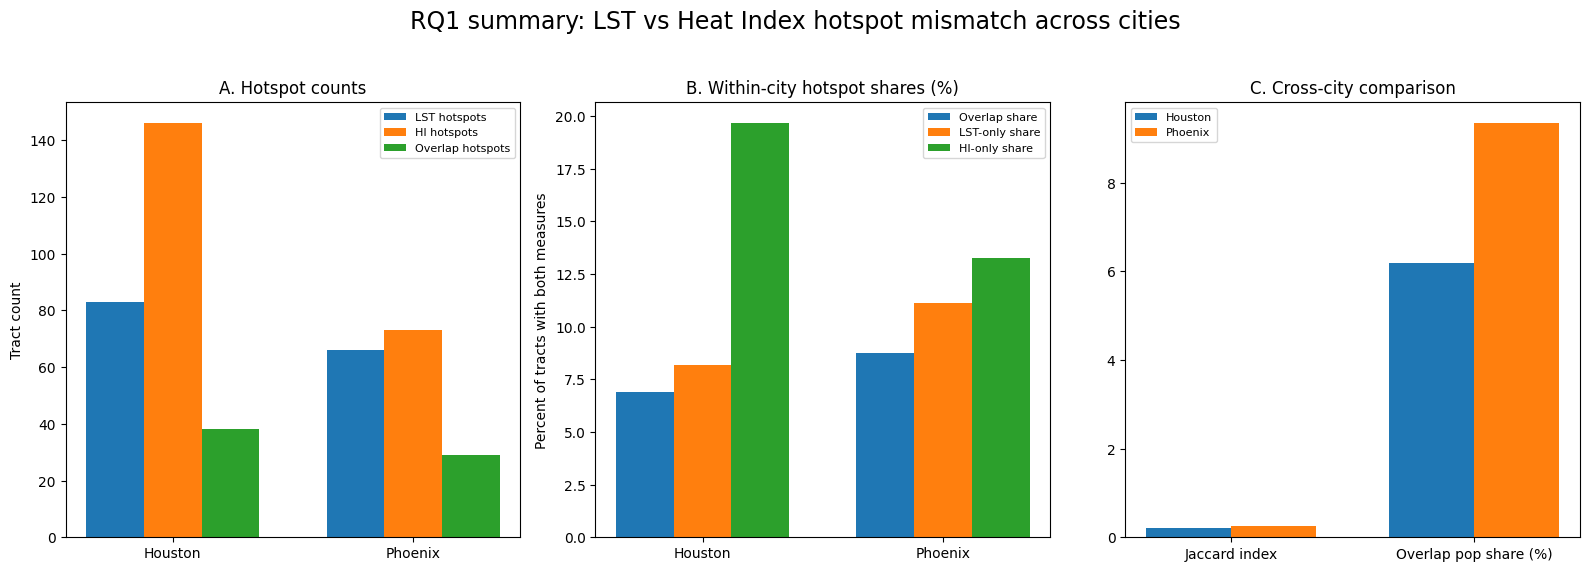

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_city_mismatch_summary_figure.png -> True


In [2]:
# ============================================================
# Cell 2
# Paper-style summary figure for RQ1 city comparison
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

summary_path = output_dir / "rq1_city_mismatch_summary.csv"
rq1_city_summary = pd.read_csv(summary_path)

display(rq1_city_summary.round(3))

cities = rq1_city_summary["city"].tolist()
x = np.arange(len(cities))
width = 0.24

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ------------------------------------------------------------
# Panel A: hotspot counts
# ------------------------------------------------------------
axes[0].bar(x - width, rq1_city_summary["lst_hotspot_n"], width, label="LST hotspots")
axes[0].bar(x, rq1_city_summary["hi_hotspot_n"], width, label="HI hotspots")
axes[0].bar(x + width, rq1_city_summary["overlap_n"], width, label="Overlap hotspots")
axes[0].set_title("A. Hotspot counts")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cities)
axes[0].set_ylabel("Tract count")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# Panel B: mismatch shares
# ------------------------------------------------------------
axes[1].bar(x - width, rq1_city_summary["overlap_share_pct"], width, label="Overlap share")
axes[1].bar(x, rq1_city_summary["lst_only_share_pct"], width, label="LST-only share")
axes[1].bar(x + width, rq1_city_summary["hi_only_share_pct"], width, label="HI-only share")
axes[1].set_title("B. Within-city hotspot shares (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cities)
axes[1].set_ylabel("Percent of tracts with both measures")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# Panel C: summary metrics
# ------------------------------------------------------------
metrics = ["jaccard_index", "overlap_pop_share_pct"]
metric_labels = ["Jaccard index", "Overlap pop share (%)"]
x2 = np.arange(len(metric_labels))
width2 = 0.35

houston_vals = rq1_city_summary.loc[rq1_city_summary["city"] == "Houston", metrics].iloc[0].values
phoenix_vals = rq1_city_summary.loc[rq1_city_summary["city"] == "Phoenix", metrics].iloc[0].values

axes[2].bar(x2 - width2/2, houston_vals, width2, label="Houston")
axes[2].bar(x2 + width2/2, phoenix_vals, width2, label="Phoenix")
axes[2].set_title("C. Cross-city comparison")
axes[2].set_xticks(x2)
axes[2].set_xticklabels(metric_labels)
axes[2].legend(fontsize=8)

fig.suptitle("RQ1 summary: LST vs Heat Index hotspot mismatch across cities", fontsize=17, y=1.03)
plt.tight_layout()

summary_fig_out = figure_dir / "rq1_city_mismatch_summary_figure.png"
plt.savefig(summary_fig_out, dpi=300, bbox_inches="tight")
plt.show()

print(summary_fig_out, "->", summary_fig_out.exists())

,city,lst_source_col,hi_source_col,population_source_col,tract_rows,valid_both_n,missing_lst_n,missing_hi_n,lst_threshold_top20_c,hi_threshold_top20_c,...,jaccard_index,overlap_share_pct,lst_only_share_pct,hi_only_share_pct,neither_share_pct,median_lst_c,median_hi_c,overlap_pop_share_pct,lst_hotspot_pop_share_pct,hi_hotspot_pop_share_pct
0,Houston,lst_c,hi_c,total_population,654,549,0,105,50.314631,34.198098,...,0.198953,6.921676,8.196721,19.672131,65.209472,48.531293,34.182125,6.188047,13.088875,24.956820
1,Phoenix,lst_c,hi_c,total_population,373,332,0,41,58.607177,33.694000,...,0.263636,8.734940,11.144578,13.253012,66.867470,57.217040,33.308242,9.343614,18.589800,23.217669


,city,Overlap hotspot,LST-only hotspot,HI-only hotspot,Neither
0,Houston,6.92,8.20,19.67,65.21
1,Phoenix,8.73,11.14,13.25,66.87


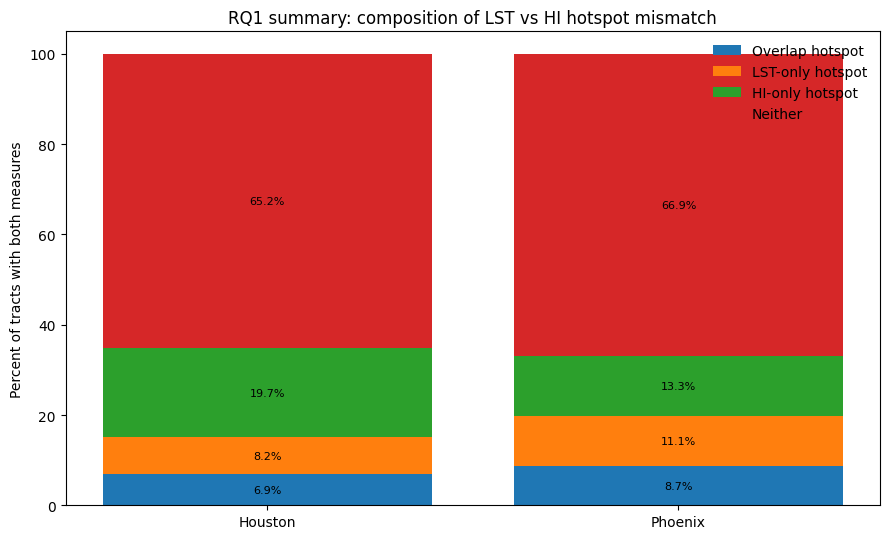

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_hotspot_composition_stackedbar.png -> True


In [4]:
# ============================================================
# Cell 4
# Paper-style hotspot composition figure
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

summary_path = output_dir / "rq1_city_mismatch_summary.csv"
rq1 = pd.read_csv(summary_path)

display(rq1.head())

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def pick_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Cannot find {label}. Tried: {candidates}. Available: {list(df.columns)}")

city_col = pick_col(rq1, ["city"], "city")
overlap_share_col = pick_col(rq1, ["overlap_share_pct"], "overlap_share_pct")
lst_only_share_col = pick_col(rq1, ["lst_only_share_pct"], "lst_only_share_pct")
hi_only_share_col = pick_col(rq1, ["hi_only_share_pct"], "hi_only_share_pct")
neither_share_col = pick_col(rq1, ["neither_share_pct"], "neither_share_pct")

plot_df = rq1[[city_col, overlap_share_col, lst_only_share_col, hi_only_share_col, neither_share_col]].copy()
plot_df.columns = ["city", "Overlap hotspot", "LST-only hotspot", "HI-only hotspot", "Neither"]

display(plot_df.round(2))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(plot_df))
bottom = np.zeros(len(plot_df))

category_order = ["Overlap hotspot", "LST-only hotspot", "HI-only hotspot", "Neither"]

for cat in category_order:
    vals = plot_df[cat].values
    ax.bar(x, vals, bottom=bottom, label=cat)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df["city"])
ax.set_ylabel("Percent of tracts with both measures")
ax.set_title("RQ1 summary: composition of LST vs HI hotspot mismatch")
ax.legend(frameon=False)

for i in range(len(plot_df)):
    y = 0
    for cat in category_order:
        v = plot_df.loc[i, cat]
        if v >= 6:
            ax.text(i, y + v/2, f"{v:.1f}%", ha="center", va="center", fontsize=8)
        y += v

plt.tight_layout()

stacked_fig_out = figure_dir / "rq1_hotspot_composition_stackedbar.png"
plt.savefig(stacked_fig_out, dpi=300, bbox_inches="tight")
plt.show()

print(stacked_fig_out, "->", stacked_fig_out.exists())

Project root: /Users/yufeizhou/Desktop/heat-exposure-compare
Houston spatial input: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_rq1_compare.gpkg
Phoenix spatial input: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_rq1_compare.gpkg


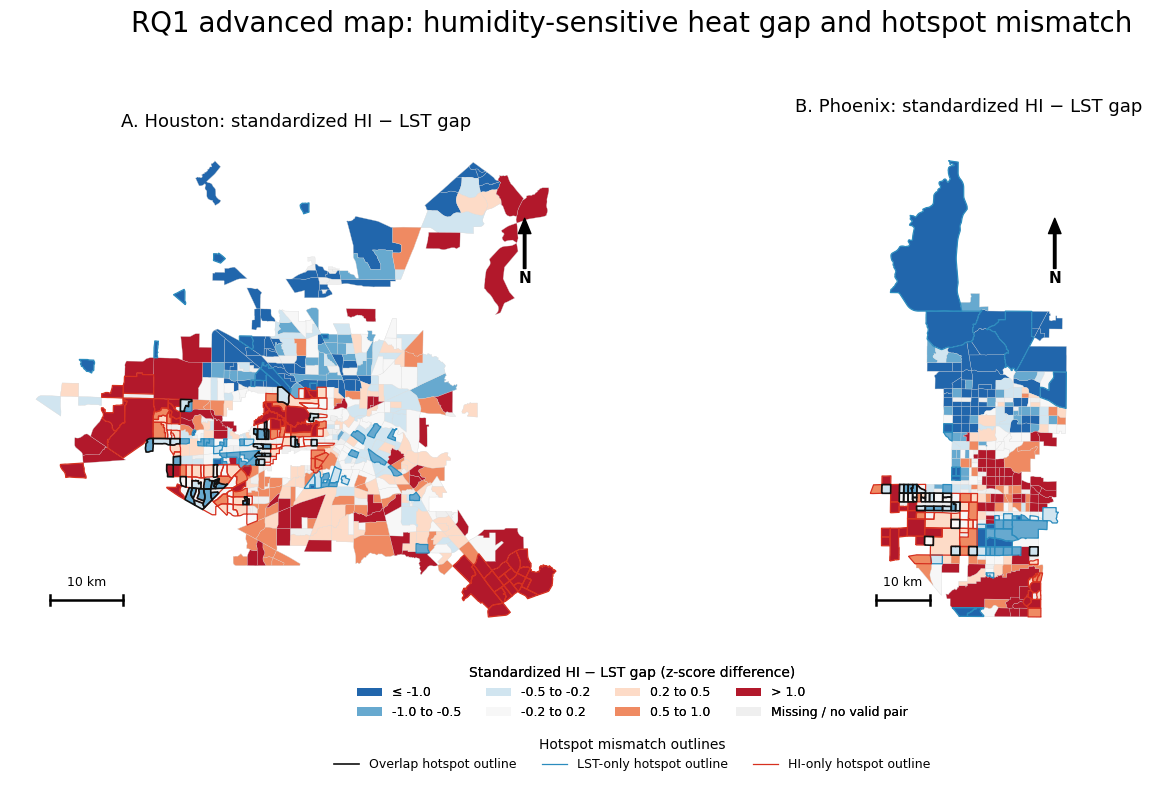

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_advanced_hi_minus_lst_gap_map.png -> True


/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,city,compare_group,n_tracts,median_hi_minus_lst_z,mean_hi_minus_lst_z,median_lst_c,median_hi_c
0,Houston,Overlap hotspot,38,-0.614,-0.535,51.592,34.199
1,Houston,LST-only hotspot,45,-0.817,-1.115,50.942,34.182
2,Houston,HI-only hotspot,108,0.703,1.091,48.461,34.199
3,Houston,Neither,358,0.080,0.029,48.022,34.172
4,Houston,Missing,105,NaN,NaN,50.153,NaN
5,Phoenix,Overlap hotspot,29,-0.244,-0.233,59.453,33.807
6,Phoenix,LST-only hotspot,37,-0.968,-1.066,59.148,33.554
7,Phoenix,HI-only hotspot,44,0.780,0.969,57.669,33.871
8,Phoenix,Neither,222,0.054,0.044,56.469,33.308
9,Phoenix,Missing,41,NaN,NaN,57.843,NaN


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_advanced_gap_map_qc.csv -> True

Quick interpretation:
Houston: overall median(HI-LST standardized gap) = 0.059; HI-only hotspot median gap = 0.703; LST-only hotspot median gap = -0.817
Phoenix: overall median(HI-LST standardized gap) = 0.009; HI-only hotspot median gap = 0.780; LST-only hotspot median gap = -0.968


In [5]:
# ============================================================
# Cell 5
# ADVANCED MAP:
# standardized HI-LST gap + hotspot mismatch outlines
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files exists:\n" + "\n".join(str(x) for x in candidates)
    )

def pick_first_column(gdf, candidates, label):
    for c in candidates:
        if c in gdf.columns:
            return c
    raise ValueError(
        f"Could not find a valid {label} column. Tried: {candidates}\n"
        f"Available columns are:\n{list(gdf.columns)}"
    )

def add_north_arrow(ax, x=0.90, y=0.84):
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - 0.10),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", width=1.8, headwidth=9, headlength=11)
    )
    ax.text(
        x, y - 0.12, "N",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=11, fontweight="bold"
    )

def add_scale_bar(ax, length_km=10):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    bar_len = length_km * 1000  # assumes projected CRS in meters
    x0 = xmin + 0.07 * (xmax - xmin)
    y0 = ymin + 0.08 * (ymax - ymin)

    ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=1.8)
    ax.plot([x0, x0], [y0 - 0.01*(ymax-ymin), y0 + 0.01*(ymax-ymin)], color="black", lw=1.8)
    ax.plot([x0 + bar_len, x0 + bar_len], [y0 - 0.01*(ymax-ymin), y0 + 0.01*(ymax-ymin)], color="black", lw=1.8)
    ax.text(
        x0 + bar_len/2,
        y0 + 0.022*(ymax-ymin),
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=9
    )

def zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        out = pd.Series(np.nan, index=s.index)
        out.loc[s.notna()] = 0.0
        return out
    return (s - mu) / sd

def ensure_compare_group(gdf):
    gdf = gdf.copy()
    gdf["has_both"] = gdf["lst_c"].notna() & gdf["hi_c"].notna()

    if "compare_group" not in gdf.columns:
        lst_thr = gdf["lst_c"].dropna().quantile(0.80)
        hi_thr = gdf["hi_c"].dropna().quantile(0.80)

        gdf["lst_hotspot"] = gdf["lst_c"] >= lst_thr
        gdf["hi_hotspot"] = gdf["hi_c"] >= hi_thr

        gdf["compare_group"] = np.select(
            [
                gdf["has_both"] & gdf["lst_hotspot"] & gdf["hi_hotspot"],
                gdf["has_both"] & gdf["lst_hotspot"] & (~gdf["hi_hotspot"]),
                gdf["has_both"] & (~gdf["lst_hotspot"]) & gdf["hi_hotspot"],
                gdf["has_both"] & (~gdf["lst_hotspot"]) & (~gdf["hi_hotspot"]),
            ],
            [
                "Overlap hotspot",
                "LST-only hotspot",
                "HI-only hotspot",
                "Neither",
            ],
            default="Missing"
        )
    else:
        gdf["compare_group"] = gdf["compare_group"].fillna("Missing")

    return gdf

def load_city_compare_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()

    lst_col = pick_first_column(
        gdf,
        ["lst_c", "lst_value", "lst_summer_median_c", "median_lst_c", "median_lst", "lst_median_c"],
        "LST"
    )
    hi_col = pick_first_column(
        gdf,
        ["hi_c", "hi_value", "hi_summer_median_c", "median_hi_c", "hi_median_c", "median_heat_index_c", "heat_index_median_c"],
        "Heat Index"
    )

    gdf["city"] = city_name
    gdf["lst_c"] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf["hi_c"] = pd.to_numeric(gdf[hi_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna()].copy()

    gdf = ensure_compare_group(gdf)

    # standardized within-city values
    gdf["lst_z"] = zscore_series(gdf["lst_c"])
    gdf["hi_z"] = zscore_series(gdf["hi_c"])

    # main advanced metric
    gdf["hi_minus_lst_z"] = gdf["hi_z"] - gdf["lst_z"]

    return gdf

def classify_gap(gdf):
    gdf = gdf.copy()

    bins = [-np.inf, -1.0, -0.5, -0.2, 0.2, 0.5, 1.0, np.inf]
    labels = [
        "≤ -1.0",
        "-1.0 to -0.5",
        "-0.5 to -0.2",
        "-0.2 to 0.2",
        "0.2 to 0.5",
        "0.5 to 1.0",
        "> 1.0"
    ]

    gdf["gap_class"] = pd.cut(
        gdf["hi_minus_lst_z"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return gdf, labels

def plot_gap_panel(ax, gdf, title, gap_labels, gap_colors):
    # base: all tracts
    gdf.plot(
        ax=ax,
        color="#efefef",
        edgecolor="#d9d9d9",
        linewidth=0.18
    )

    # fill valid tracts by HI-LST gap
    for label, color in zip(gap_labels, gap_colors):
        sub = gdf.loc[gdf["gap_class"] == label]
        if len(sub) > 0:
            sub.plot(
                ax=ax,
                color=color,
                edgecolor="#dddddd",
                linewidth=0.18
            )

    # hotspot mismatch outlines
    outline_specs = [
        ("LST-only hotspot", "#2b8cbe", 0.9),
        ("HI-only hotspot", "#d7301f", 0.9),
        ("Overlap hotspot", "#111111", 1.2),
    ]

    for grp, color, lw in outline_specs:
        sub = gdf.loc[gdf["compare_group"] == grp]
        if len(sub) > 0:
            sub.boundary.plot(ax=ax, color=color, linewidth=lw)

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scale_bar(ax, length_km=10)

# ------------------------------------------------------------
# input files
# ------------------------------------------------------------
houston_path = first_existing([
    project_root / "data_processed" / "houston" / "houston_rq1_compare.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
])

phoenix_path = first_existing([
    project_root / "data_processed" / "phoenix" / "phoenix_rq1_compare.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
])

print("Houston spatial input:", houston_path)
print("Phoenix spatial input:", phoenix_path)

houston = load_city_compare_gdf(houston_path, "Houston")
phoenix = load_city_compare_gdf(phoenix_path, "Phoenix")

houston, gap_labels = classify_gap(houston)
phoenix, _ = classify_gap(phoenix)

# ------------------------------------------------------------
# colors for standardized HI-LST gap
# negative = LST relatively stronger
# positive = HI relatively stronger
# ------------------------------------------------------------
gap_colors = [
    "#2166ac",  # strong negative
    "#67a9cf",
    "#d1e5f0",
    "#f7f7f7",
    "#fddbc7",
    "#ef8a62",
    "#b2182b",  # strong positive
]

# ------------------------------------------------------------
# plot main advanced map
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

plot_gap_panel(
    axes[0],
    houston,
    "A. Houston: standardized HI − LST gap",
    gap_labels,
    gap_colors
)

plot_gap_panel(
    axes[1],
    phoenix,
    "B. Phoenix: standardized HI − LST gap",
    gap_labels,
    gap_colors
)

fig.suptitle(
    "RQ1 advanced map: humidity-sensitive heat gap and hotspot mismatch",
    fontsize=20,
    y=0.98
)

fill_handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(gap_colors, gap_labels)]
fill_handles.append(Patch(facecolor="#efefef", edgecolor="none", label="Missing / no valid pair"))

line_handles = [
    Line2D([0], [0], color="#111111", lw=1.2, label="Overlap hotspot outline"),
    Line2D([0], [0], color="#2b8cbe", lw=0.9, label="LST-only hotspot outline"),
    Line2D([0], [0], color="#d7301f", lw=0.9, label="HI-only hotspot outline"),
]

leg1 = fig.legend(
    handles=fill_handles,
    title="Standardized HI − LST gap (z-score difference)",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    frameon=False,
    fontsize=9,
    title_fontsize=10
)
leg2 = fig.legend(
    handles=line_handles,
    title="Hotspot mismatch outlines",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    fontsize=9,
    title_fontsize=10
)
fig.add_artist(leg1)

plt.tight_layout(rect=[0, 0.12, 1, 0.94])

advanced_map_out = figure_dir / "rq1_advanced_hi_minus_lst_gap_map.png"
plt.savefig(advanced_map_out, dpi=300, bbox_inches="tight")
plt.show()

print(advanced_map_out, "->", advanced_map_out.exists())

# ------------------------------------------------------------
# QC table for paper interpretation
# ------------------------------------------------------------
qc_rows = []
for city_name, gdf in [("Houston", houston), ("Phoenix", phoenix)]:
    for grp in ["Overlap hotspot", "LST-only hotspot", "HI-only hotspot", "Neither", "Missing"]:
        sub = gdf.loc[gdf["compare_group"] == grp].copy()
        qc_rows.append({
            "city": city_name,
            "compare_group": grp,
            "n_tracts": len(sub),
            "median_hi_minus_lst_z": sub["hi_minus_lst_z"].median() if len(sub) > 0 else np.nan,
            "mean_hi_minus_lst_z": sub["hi_minus_lst_z"].mean() if len(sub) > 0 else np.nan,
            "median_lst_c": sub["lst_c"].median() if len(sub) > 0 else np.nan,
            "median_hi_c": sub["hi_c"].median() if len(sub) > 0 else np.nan,
        })

gap_qc = pd.DataFrame(qc_rows)
display(gap_qc.round(3))

gap_qc_out = output_dir / "rq1_advanced_gap_map_qc.csv"
gap_qc.to_csv(gap_qc_out, index=False)
print(gap_qc_out, "->", gap_qc_out.exists())

# ------------------------------------------------------------
# quick interpretation
# ------------------------------------------------------------
print("\nQuick interpretation:")
for city_name, gdf in [("Houston", houston), ("Phoenix", phoenix)]:
    city_med = gdf["hi_minus_lst_z"].median()
    hi_only_med = gdf.loc[gdf["compare_group"] == "HI-only hotspot", "hi_minus_lst_z"].median()
    lst_only_med = gdf.loc[gdf["compare_group"] == "LST-only hotspot", "hi_minus_lst_z"].median()

    print(
        f"{city_name}: overall median(HI-LST standardized gap) = {city_med:.3f}; "
        f"HI-only hotspot median gap = {hi_only_med:.3f}; "
        f"LST-only hotspot median gap = {lst_only_med:.3f}"
    )

In [6]:
# ============================================================
# Cell 6
# PAPER-READY ASSETS FOR RQ1
# summary table + results notes + figure captions
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files exists:\n" + "\n".join(str(x) for x in candidates)
    )

def pick_first_column(gdf, candidates, label):
    for c in candidates:
        if c in gdf.columns:
            return c
    raise ValueError(
        f"Could not find a valid {label} column. Tried: {candidates}\n"
        f"Available columns:\n{list(gdf.columns)}"
    )

def zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        out = pd.Series(np.nan, index=s.index)
        out.loc[s.notna()] = 0.0
        return out
    return (s - mu) / sd

def load_city_compare_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()

    lst_col = pick_first_column(
        gdf,
        ["lst_c", "lst_value", "lst_summer_median_c", "median_lst_c", "median_lst", "lst_median_c"],
        "LST"
    )
    hi_col = pick_first_column(
        gdf,
        ["hi_c", "hi_value", "hi_summer_median_c", "median_hi_c", "hi_median_c", "median_heat_index_c", "heat_index_median_c"],
        "Heat Index"
    )

    gdf["city"] = city_name
    gdf["lst_c"] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf["hi_c"] = pd.to_numeric(gdf[hi_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna()].copy()

    gdf["has_both"] = gdf["lst_c"].notna() & gdf["hi_c"].notna()

    lst_thr = gdf.loc[gdf["lst_c"].notna(), "lst_c"].quantile(0.80)
    hi_thr = gdf.loc[gdf["hi_c"].notna(), "hi_c"].quantile(0.80)

    gdf["lst_hotspot"] = gdf["lst_c"] >= lst_thr
    gdf["hi_hotspot"] = gdf["hi_c"] >= hi_thr

    gdf["compare_group"] = np.select(
        [
            gdf["has_both"] & gdf["lst_hotspot"] & gdf["hi_hotspot"],
            gdf["has_both"] & gdf["lst_hotspot"] & (~gdf["hi_hotspot"]),
            gdf["has_both"] & (~gdf["lst_hotspot"]) & gdf["hi_hotspot"],
            gdf["has_both"] & (~gdf["lst_hotspot"]) & (~gdf["hi_hotspot"]),
        ],
        [
            "Overlap hotspot",
            "LST-only hotspot",
            "HI-only hotspot",
            "Neither",
        ],
        default="Missing"
    )

    gdf["lst_z"] = zscore_series(gdf["lst_c"])
    gdf["hi_z"] = zscore_series(gdf["hi_c"])
    gdf["hi_minus_lst_z"] = gdf["hi_z"] - gdf["lst_z"]

    return gdf, lst_thr, hi_thr

# ------------------------------------------------------------
# load files
# ------------------------------------------------------------
houston_path = first_existing([
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "houston" / "houston_rq1_compare.gpkg",
])

phoenix_path = first_existing([
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_rq1_compare.gpkg",
])

houston, houston_lst_thr, houston_hi_thr = load_city_compare_gdf(houston_path, "Houston")
phoenix, phoenix_lst_thr, phoenix_hi_thr = load_city_compare_gdf(phoenix_path, "Phoenix")

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
summary_rows = []

for city_name, gdf, lst_thr, hi_thr in [
    ("Houston", houston, houston_lst_thr, houston_hi_thr),
    ("Phoenix", phoenix, phoenix_lst_thr, phoenix_hi_thr),
]:
    valid = gdf.loc[gdf["has_both"]].copy()

    overlap_n = (gdf["compare_group"] == "Overlap hotspot").sum()
    lst_only_n = (gdf["compare_group"] == "LST-only hotspot").sum()
    hi_only_n = (gdf["compare_group"] == "HI-only hotspot").sum()
    neither_n = (gdf["compare_group"] == "Neither").sum()
    missing_n = (gdf["compare_group"] == "Missing").sum()

    union_n = overlap_n + lst_only_n + hi_only_n
    jaccard = overlap_n / union_n if union_n > 0 else np.nan

    valid_n = len(valid)

    summary_rows.append({
        "city": city_name,
        "tract_rows": len(gdf),
        "valid_both_n": valid_n,
        "missing_hi_n": int(gdf["hi_c"].isna().sum()),
        "median_lst_c": gdf["lst_c"].median(),
        "median_hi_c": gdf["hi_c"].median(),
        "lst_hotspot_threshold_top20_c": lst_thr,
        "hi_hotspot_threshold_top20_c": hi_thr,
        "lst_hotspot_n": int(gdf["lst_hotspot"].sum()),
        "hi_hotspot_n": int(gdf["hi_hotspot"].sum()),
        "overlap_n": overlap_n,
        "lst_only_n": lst_only_n,
        "hi_only_n": hi_only_n,
        "neither_n": neither_n,
        "missing_group_n": missing_n,
        "jaccard_index": jaccard,
        "overlap_share_pct": overlap_n / valid_n * 100 if valid_n > 0 else np.nan,
        "lst_only_share_pct": lst_only_n / valid_n * 100 if valid_n > 0 else np.nan,
        "hi_only_share_pct": hi_only_n / valid_n * 100 if valid_n > 0 else np.nan,
        "median_hi_minus_lst_z": valid["hi_minus_lst_z"].median() if valid_n > 0 else np.nan,
    })

rq1_summary_table = pd.DataFrame(summary_rows)
display(rq1_summary_table.round(3))

summary_csv = output_dir / "rq1_paper_summary_table.csv"
rq1_summary_table.to_csv(summary_csv, index=False)
print(summary_csv, "->", summary_csv.exists())

# ------------------------------------------------------------
# long-format group table
# ------------------------------------------------------------
group_rows = []
for city_name, gdf in [("Houston", houston), ("Phoenix", phoenix)]:
    for grp in ["Overlap hotspot", "LST-only hotspot", "HI-only hotspot", "Neither", "Missing"]:
        sub = gdf.loc[gdf["compare_group"] == grp].copy()
        group_rows.append({
            "city": city_name,
            "compare_group": grp,
            "n_tracts": len(sub),
            "share_of_all_tracts_pct": len(sub) / len(gdf) * 100 if len(gdf) > 0 else np.nan,
            "median_lst_c": sub["lst_c"].median() if len(sub) > 0 else np.nan,
            "median_hi_c": sub["hi_c"].median() if len(sub) > 0 else np.nan,
            "median_hi_minus_lst_z": sub["hi_minus_lst_z"].median() if len(sub) > 0 else np.nan,
        })

rq1_group_table = pd.DataFrame(group_rows)
display(rq1_group_table.round(3))

group_csv = output_dir / "rq1_paper_group_breakdown.csv"
rq1_group_table.to_csv(group_csv, index=False)
print(group_csv, "->", group_csv.exists())

# ------------------------------------------------------------
# results notes for paper drafting
# ------------------------------------------------------------
h = rq1_summary_table.loc[rq1_summary_table["city"] == "Houston"].iloc[0]
p = rq1_summary_table.loc[rq1_summary_table["city"] == "Phoenix"].iloc[0]

results_notes = f"""# RQ1 paper-ready results notes

## Core result
This analysis compares Land Surface Temperature (LST) and Heat Index (HI) at the tract level in Houston and Phoenix.

## Main findings
- In Houston, the hotspot overlap between LST and HI is limited rather than complete. The Jaccard index is {h['jaccard_index']:.3f}, and overlap hotspots account for {h['overlap_share_pct']:.1f}% of tracts with both measures.
- In Houston, LST-only hotspots account for {h['lst_only_share_pct']:.1f}% of valid tracts, while HI-only hotspots account for {h['hi_only_share_pct']:.1f}%. This suggests that the two measures capture partly different heat-risk areas.
- In Phoenix, the hotspot overlap is also incomplete. The Jaccard index is {p['jaccard_index']:.3f}, and overlap hotspots account for {p['overlap_share_pct']:.1f}% of tracts with both measures.
- In Phoenix, LST-only hotspots account for {p['lst_only_share_pct']:.1f}% of valid tracts, while HI-only hotspots account for {p['hi_only_share_pct']:.1f}% of valid tracts.
- The median standardized HI−LST gap is {h['median_hi_minus_lst_z']:.2f} in Houston and {p['median_hi_minus_lst_z']:.2f} in Phoenix. Positive values indicate places where humidity-sensitive heat exposure is stronger relative to surface heat.

## Interpretation
- LST alone does not fully reproduce the spatial pattern of HI-defined heat exposure.
- The mismatch between LST-only and HI-only hotspots supports the main RQ1 argument that humidity matters for identifying heat-risk areas.
- The original-value choropleth maps show the broad spatial distribution of each variable, while the hotspot mismatch map directly identifies where the two measures agree and differ.
- The standardized HI−LST gap map provides an additional interpretation layer by showing where humidity-sensitive heat is relatively stronger or weaker.

## Method note
- Hotspots are defined separately within each city and each measure as the top 20% of tracts.
- The hotspot overlap metric is summarized using the Jaccard index:
  Jaccard = overlap / (overlap + LST-only + HI-only)

"""

results_md = output_dir / "rq1_paper_results_notes.md"
results_md.write_text(results_notes, encoding="utf-8")
print(results_md, "->", results_md.exists())

print("\n----- results notes preview -----\n")
print(results_notes)

# ------------------------------------------------------------
# figure captions
# ------------------------------------------------------------
captions_text = """# RQ1 figure captions

## Figure 1. Original values of LST and Heat Index across census tracts
This figure shows tract-level choropleth maps of median summer Land Surface Temperature (LST, °C) and median summer Heat Index (HI, °C) for Houston and Phoenix. The maps provide the original spatial distributions of the two measures before hotspot classification. They are used to compare broad spatial gradients and identify areas with relatively high background thermal burden.

## Figure 2. Hotspot mismatch between LST and Heat Index
This figure maps the spatial overlap and mismatch between LST hotspots and HI hotspots. For each city and each measure, hotspots are defined as the top 20% of tracts. Red tracts indicate overlap hotspots, orange tracts indicate LST-only hotspots, and blue tracts indicate HI-only hotspots. This figure directly addresses the main RQ1 question by showing where the two metrics agree and where they diverge.

## Figure 3. Standardized HI−LST gap map
This figure shows the standardized difference between Heat Index and Land Surface Temperature at the tract level, calculated as HI z-score minus LST z-score within each city. Positive values indicate tracts where humidity-sensitive heat exposure is relatively stronger than surface heat, while negative values indicate tracts where surface heat is relatively stronger. Hotspot mismatch outlines are added to connect the continuous gap pattern to the hotspot results.
"""

captions_md = output_dir / "rq1_figure_captions.md"
captions_md.write_text(captions_text, encoding="utf-8")
print(captions_md, "->", captions_md.exists())

print("\n----- captions preview -----\n")
print(captions_text)

# ------------------------------------------------------------
# final output file check
# ------------------------------------------------------------
print("\nFINAL OUTPUT CHECK:")
for pth in [summary_csv, group_csv, results_md, captions_md]:
    print(pth, "->", pth.exists())

Project root: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,tract_rows,valid_both_n,missing_hi_n,median_lst_c,median_hi_c,lst_hotspot_threshold_top20_c,hi_hotspot_threshold_top20_c,lst_hotspot_n,hi_hotspot_n,overlap_n,lst_only_n,hi_only_n,neither_n,missing_group_n,jaccard_index,overlap_share_pct,lst_only_share_pct,hi_only_share_pct,median_hi_minus_lst_z
0,Houston,654,549,105,48.531,34.182,50.315,34.198,131,146,38,45,108,358,105,0.199,6.922,8.197,19.672,0.059
1,Phoenix,373,332,41,57.217,33.308,58.607,33.694,75,73,29,37,44,222,41,0.264,8.735,11.145,13.253,0.009


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_paper_summary_table.csv -> True


/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,city,compare_group,n_tracts,share_of_all_tracts_pct,median_lst_c,median_hi_c,median_hi_minus_lst_z
0,Houston,Overlap hotspot,38,5.810,51.592,34.199,-0.614
1,Houston,LST-only hotspot,45,6.881,50.942,34.182,-0.817
2,Houston,HI-only hotspot,108,16.514,48.461,34.199,0.703
3,Houston,Neither,358,54.740,48.022,34.172,0.080
4,Houston,Missing,105,16.055,50.153,NaN,NaN
5,Phoenix,Overlap hotspot,29,7.775,59.453,33.807,-0.244
6,Phoenix,LST-only hotspot,37,9.920,59.148,33.554,-0.968
7,Phoenix,HI-only hotspot,44,11.796,57.669,33.871,0.780
8,Phoenix,Neither,222,59.517,56.469,33.308,0.054
9,Phoenix,Missing,41,10.992,57.843,NaN,NaN


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_paper_group_breakdown.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_paper_results_notes.md -> True

----- results notes preview -----

# RQ1 paper-ready results notes

## Core result
This analysis compares Land Surface Temperature (LST) and Heat Index (HI) at the tract level in Houston and Phoenix.

## Main findings
- In Houston, the hotspot overlap between LST and HI is limited rather than complete. The Jaccard index is 0.199, and overlap hotspots account for 6.9% of tracts with both measures.
- In Houston, LST-only hotspots account for 8.2% of valid tracts, while HI-only hotspots account for 19.7%. This suggests that the two measures capture partly different heat-risk areas.
- In Phoenix, the hotspot overlap is also incomplete. The Jaccard index is 0.264, and overlap hotspots account for 8.7% of tracts with both measures.
- In Phoenix, LST-only hotspots account for 11.1% of valid tracts, w

In [7]:
# ============================================================
# Cell 7
# PAPER STRUCTURE ASSETS:
# figure plan + results draft + methods draft
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def first_existing_or_none(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

def pick_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Cannot find {label}. Tried: {candidates}. Available: {list(df.columns)}")

# ------------------------------------------------------------
# load current summary outputs
# ------------------------------------------------------------
summary_path = output_dir / "rq1_paper_summary_table.csv"
group_path = output_dir / "rq1_paper_group_breakdown.csv"

rq1_summary = pd.read_csv(summary_path)
rq1_group = pd.read_csv(group_path)

display(rq1_summary.round(3))
display(rq1_group.round(3))

city_col = pick_col(rq1_summary, ["city"], "city")
jaccard_col = pick_col(rq1_summary, ["jaccard_index"], "jaccard_index")
overlap_share_col = pick_col(rq1_summary, ["overlap_share_pct"], "overlap_share_pct")
lst_only_share_col = pick_col(rq1_summary, ["lst_only_share_pct"], "lst_only_share_pct")
hi_only_share_col = pick_col(rq1_summary, ["hi_only_share_pct"], "hi_only_share_pct")
median_lst_col = pick_col(rq1_summary, ["median_lst_c"], "median_lst_c")
median_hi_col = pick_col(rq1_summary, ["median_hi_c"], "median_hi_c")
gap_col = pick_col(rq1_summary, ["median_hi_minus_lst_z"], "median_hi_minus_lst_z")
valid_col = pick_col(rq1_summary, ["valid_both_n"], "valid_both_n")
missing_hi_col = pick_col(rq1_summary, ["missing_hi_n"], "missing_hi_n")

h = rq1_summary.loc[rq1_summary[city_col] == "Houston"].iloc[0]
p = rq1_summary.loc[rq1_summary[city_col] == "Phoenix"].iloc[0]

# group breakdown helpers
group_city_col = pick_col(rq1_group, ["city"], "group city")
group_name_col = pick_col(rq1_group, ["compare_group"], "compare_group")
group_gap_col = pick_col(rq1_group, ["median_hi_minus_lst_z"], "group median_hi_minus_lst_z")

def get_group_gap(df, city, group_name):
    sub = df.loc[(df[group_city_col] == city) & (df[group_name_col] == group_name)]
    if len(sub) == 0:
        return np.nan
    return float(sub.iloc[0][group_gap_col])

h_hi_only_gap = get_group_gap(rq1_group, "Houston", "HI-only hotspot")
h_lst_only_gap = get_group_gap(rq1_group, "Houston", "LST-only hotspot")
p_hi_only_gap = get_group_gap(rq1_group, "Phoenix", "HI-only hotspot")
p_lst_only_gap = get_group_gap(rq1_group, "Phoenix", "LST-only hotspot")

# ------------------------------------------------------------
# detect figure files
# ------------------------------------------------------------
fig_original = first_existing_or_none([
    figure_dir / "teacher_ready_original_values_choropleth_polished.png",
    figure_dir / "teacher_ready_original_values_choropleth.png",
])

fig_hotspot = first_existing_or_none([
    figure_dir / "teacher_ready_lst_vs_hi_hotspot_compare.png",
    figure_dir / "rq1_lst_hi_hotspot_compare.png",
])

fig_gap = first_existing_or_none([
    figure_dir / "rq1_advanced_hi_minus_lst_gap_map.png",
])

# ------------------------------------------------------------
# figure plan
# ------------------------------------------------------------
figure_plan = pd.DataFrame([
    {
        "order": 1,
        "paper_slot": "Main Figure 1",
        "asset_type": "Map",
        "working_name": "LST vs HI hotspot mismatch",
        "filename": str(fig_hotspot) if fig_hotspot is not None else "MISSING",
        "status": "ready" if fig_hotspot is not None else "missing",
        "main_message": "Directly shows where LST and Heat Index hotspots overlap or diverge.",
        "why_it_matters": "This is the clearest visual for the core RQ1 comparison."
    },
    {
        "order": 2,
        "paper_slot": "Main Figure 2",
        "asset_type": "Map",
        "working_name": "Original-value choropleth",
        "filename": str(fig_original) if fig_original is not None else "MISSING",
        "status": "ready" if fig_original is not None else "missing",
        "main_message": "Shows the original tract-level spatial distributions of LST and HI.",
        "why_it_matters": "Provides the baseline spatial context requested by the advisor."
    },
    {
        "order": 3,
        "paper_slot": "Supporting Figure 1",
        "asset_type": "Map",
        "working_name": "Standardized HI−LST gap",
        "filename": str(fig_gap) if fig_gap is not None else "MISSING",
        "status": "ready" if fig_gap is not None else "missing",
        "main_message": "Shows where humidity-sensitive heat is relatively stronger or weaker than surface heat.",
        "why_it_matters": "Adds interpretation beyond binary hotspot agreement."
    },
    {
        "order": 4,
        "paper_slot": "Table 1",
        "asset_type": "Table",
        "working_name": "RQ1 city summary table",
        "filename": str(summary_path),
        "status": "ready",
        "main_message": "Summarizes overlap, mismatch, thresholds, and central tendency by city.",
        "why_it_matters": "Provides the quantitative evidence behind the maps."
    },
    {
        "order": 5,
        "paper_slot": "Supporting Table 1",
        "asset_type": "Table",
        "working_name": "RQ1 group breakdown",
        "filename": str(group_path),
        "status": "ready",
        "main_message": "Breaks results into overlap, LST-only, HI-only, neither, and missing groups.",
        "why_it_matters": "Supports deeper interpretation of mismatch structure."
    },
])

display(figure_plan)

figure_plan_out = output_dir / "rq1_figure_plan.csv"
figure_plan.to_csv(figure_plan_out, index=False)

# ------------------------------------------------------------
# paper-ready results draft
# ------------------------------------------------------------
results_draft = f"""# RQ1 results draft

## Results paragraph draft 1
We compared tract-level Land Surface Temperature (LST) and Heat Index (HI) in Houston and Phoenix to evaluate whether LST alone can recover the spatial pattern of humidity-informed heat exposure. In Houston, the hotspot overlap between the two measures was limited rather than complete: the Jaccard index was {h[jaccard_col]:.3f}, overlap hotspots accounted for {h[overlap_share_col]:.1f}% of valid tracts, LST-only hotspots accounted for {h[lst_only_share_col]:.1f}%, and HI-only hotspots accounted for {h[hi_only_share_col]:.1f}%. In Phoenix, the overlap was also incomplete, with a Jaccard index of {p[jaccard_col]:.3f}, an overlap share of {p[overlap_share_col]:.1f}%, an LST-only share of {p[lst_only_share_col]:.1f}%, and an HI-only share of {p[hi_only_share_col]:.1f}%.

## Results paragraph draft 2
The original-value choropleth maps show that both LST and HI vary spatially within each city, but the hotspot mismatch maps demonstrate that the two metrics do not identify exactly the same high-risk tracts. Median LST was {h[median_lst_col]:.2f}°C in Houston and {p[median_lst_col]:.2f}°C in Phoenix, while median HI was {h[median_hi_col]:.2f}°C in Houston and {p[median_hi_col]:.2f}°C in Phoenix. The standardized HI−LST gap maps add an interpretation layer by highlighting where humidity-sensitive heat is relatively stronger than surface heat. In Houston, the median HI-only hotspot gap was {h_hi_only_gap:.3f}, whereas the median LST-only hotspot gap was {h_lst_only_gap:.3f}. In Phoenix, the median HI-only hotspot gap was {p_hi_only_gap:.3f}, whereas the median LST-only hotspot gap was {p_lst_only_gap:.3f}. These patterns support the interpretation that LST alone does not fully capture the spatial distribution of HI-defined heat exposure.

## Short results bullets
- Houston: Jaccard = {h[jaccard_col]:.3f}; overlap = {h[overlap_share_col]:.1f}% of valid tracts.
- Houston: HI-only hotspots ({h[hi_only_share_col]:.1f}%) exceed LST-only hotspots ({h[lst_only_share_col]:.1f}%).
- Phoenix: Jaccard = {p[jaccard_col]:.3f}; overlap = {p[overlap_share_col]:.1f}% of valid tracts.
- Phoenix: HI-only hotspots ({p[hi_only_share_col]:.1f}%) also remain substantial relative to LST-only hotspots ({p[lst_only_share_col]:.1f}%).
- Across both cities, the mismatch between LST and HI hotspots suggests that humidity-sensitive exposure is not fully captured by LST alone.
"""

results_draft_out = output_dir / "rq1_results_draft.md"
results_draft_out.write_text(results_draft, encoding="utf-8")

print("\n----- results draft preview -----\n")
print(results_draft)

# ------------------------------------------------------------
# methods / workflow draft
# ------------------------------------------------------------
methods_draft = f"""# RQ1 methods draft

## Study design
This pilot analysis focuses on two cities, Houston and Phoenix, and compares tract-level Land Surface Temperature (LST) with tract-level Heat Index (HI).

## Core inputs
- Tract-level LST values were derived from the processed summer LST workflow.
- Tract-level HI values were derived from the processed heat-index workflow.
- The analysis was conducted on census tracts with valid geometry and available LST/HI values.

## Hotspot definition
Hotspots were defined separately within each city and separately for each measure as the top 20% of tracts.

## Comparison framework
Each tract was assigned to one of five categories:
- Overlap hotspot
- LST-only hotspot
- HI-only hotspot
- Neither
- Missing

## Quantitative metrics
The comparison was summarized using:
- hotspot counts
- overlap share
- LST-only share
- HI-only share
- Jaccard index

The Jaccard index is defined as:
Jaccard = overlap / (overlap + LST-only + HI-only)

## Continuous interpretation layer
To interpret relative humidity-sensitive heat exposure, we also computed a standardized gap:
HI_z − LST_z

Positive values indicate tracts where HI is relatively stronger than LST, while negative values indicate tracts where LST is relatively stronger than HI.

## Current city-level data coverage
- Houston valid tracts with both measures: {int(h[valid_col])}
- Houston missing HI tracts: {int(h[missing_hi_col])}
- Phoenix valid tracts with both measures: {int(p[valid_col])}
- Phoenix missing HI tracts: {int(p[missing_hi_col])}
"""

methods_draft_out = output_dir / "rq1_methods_draft.md"
methods_draft_out.write_text(methods_draft, encoding="utf-8")

print("\n----- methods draft preview -----\n")
print(methods_draft)

# ------------------------------------------------------------
# advisor update draft
# ------------------------------------------------------------
advisor_update = f"""# Short advisor update draft

I now have a more structured RQ1 package for the Houston–Phoenix pilot comparison.

Current outputs include:
1. original-value choropleth maps for LST vs Heat Index,
2. hotspot mismatch maps showing overlap / LST-only / HI-only patterns,
3. a standardized HI−LST gap map for interpretation,
4. a city-level summary table with Jaccard index and mismatch shares.

At this stage, the quantitative results suggest that hotspot overlap is limited rather than complete in both cities (Houston Jaccard = {h[jaccard_col]:.3f}; Phoenix Jaccard = {p[jaccard_col]:.3f}), which supports the RQ1 idea that LST alone does not fully recover humidity-sensitive heat exposure.
"""

advisor_update_out = output_dir / "rq1_advisor_update_draft.md"
advisor_update_out.write_text(advisor_update, encoding="utf-8")

print("\n----- advisor update preview -----\n")
print(advisor_update)

# ------------------------------------------------------------
# final file check
# ------------------------------------------------------------
print("\nFINAL PAPER-ASSET FILE CHECK:")
for pth in [
    figure_plan_out,
    results_draft_out,
    methods_draft_out,
    advisor_update_out,
]:
    print(pth, "->", pth.exists())

Project root: /Users/yufeizhou/Desktop/heat-exposure-compare


,city,tract_rows,valid_both_n,missing_hi_n,median_lst_c,median_hi_c,lst_hotspot_threshold_top20_c,hi_hotspot_threshold_top20_c,lst_hotspot_n,hi_hotspot_n,overlap_n,lst_only_n,hi_only_n,neither_n,missing_group_n,jaccard_index,overlap_share_pct,lst_only_share_pct,hi_only_share_pct,median_hi_minus_lst_z
0,Houston,654,549,105,48.531,34.182,50.315,34.198,131,146,38,45,108,358,105,0.199,6.922,8.197,19.672,0.059
1,Phoenix,373,332,41,57.217,33.308,58.607,33.694,75,73,29,37,44,222,41,0.264,8.735,11.145,13.253,0.009


,city,compare_group,n_tracts,share_of_all_tracts_pct,median_lst_c,median_hi_c,median_hi_minus_lst_z
0,Houston,Overlap hotspot,38,5.810,51.592,34.199,-0.614
1,Houston,LST-only hotspot,45,6.881,50.942,34.182,-0.817
2,Houston,HI-only hotspot,108,16.514,48.461,34.199,0.703
3,Houston,Neither,358,54.740,48.022,34.172,0.080
4,Houston,Missing,105,16.055,50.153,NaN,NaN
5,Phoenix,Overlap hotspot,29,7.775,59.453,33.807,-0.244
6,Phoenix,LST-only hotspot,37,9.920,59.148,33.554,-0.968
7,Phoenix,HI-only hotspot,44,11.796,57.669,33.871,0.780
8,Phoenix,Neither,222,59.517,56.469,33.308,0.054
9,Phoenix,Missing,41,10.992,57.843,NaN,NaN


,order,paper_slot,asset_type,working_name,filename,status,main_message,why_it_matters
0,1,Main Figure 1,Map,LST vs HI hotspot mismatch,/Users/yufeizhou/Desktop/heat-exposure-compare...,ready,Directly shows where LST and Heat Index hotspo...,This is the clearest visual for the core RQ1 c...
1,2,Main Figure 2,Map,Original-value choropleth,/Users/yufeizhou/Desktop/heat-exposure-compare...,ready,Shows the original tract-level spatial distrib...,Provides the baseline spatial context requeste...
2,3,Supporting Figure 1,Map,Standardized HI−LST gap,/Users/yufeizhou/Desktop/heat-exposure-compare...,ready,Shows where humidity-sensitive heat is relativ...,Adds interpretation beyond binary hotspot agre...
3,4,Table 1,Table,RQ1 city summary table,/Users/yufeizhou/Desktop/heat-exposure-compare...,ready,"Summarizes overlap, mismatch, thresholds, and ...",Provides the quantitative evidence behind the ...
4,5,Supporting Table 1,Table,RQ1 group breakdown,/Users/yufeizhou/Desktop/heat-exposure-compare...,ready,"Breaks results into overlap, LST-only, HI-only...",Supports deeper interpretation of mismatch str...



----- results draft preview -----

# RQ1 results draft

## Results paragraph draft 1
We compared tract-level Land Surface Temperature (LST) and Heat Index (HI) in Houston and Phoenix to evaluate whether LST alone can recover the spatial pattern of humidity-informed heat exposure. In Houston, the hotspot overlap between the two measures was limited rather than complete: the Jaccard index was 0.199, overlap hotspots accounted for 6.9% of valid tracts, LST-only hotspots accounted for 8.2%, and HI-only hotspots accounted for 19.7%. In Phoenix, the overlap was also incomplete, with a Jaccard index of 0.264, an overlap share of 8.7%, an LST-only share of 11.1%, and an HI-only share of 13.3%.

## Results paragraph draft 2
The original-value choropleth maps show that both LST and HI vary spatially within each city, but the hotspot mismatch maps demonstrate that the two metrics do not identify exactly the same high-risk tracts. Median LST was 48.53°C in Houston and 57.22°C in Phoenix, while me